# 02-1. 하이브리드 RAG 평가 — 검색기 구현과 지표 비교

`02`에서 만든 청크 308건 + 질문 30개로 검색 방식을 비교한다.

## 무엇을 비교하는가

실제로 구현 가능한 선택지만 비교한다. 이론적으로 좋은 방법이 아니라,
**우리 Postgres에 실제로 넣을 수 있는 것**이어야 결정에 쓸 수 있다.

| 검색기 | 원리 | 실제 구현 시 대응물 |
|---|---|---|
| `dense` | 코사인 유사도 (현재 운영 방식) | 지금 `search_similar_chunks` 그대로 |
| `bm25_ws` | 공백 단위 토큰 BM25 | Postgres 내장 FTS `to_tsvector('simple', ...)` |
| `bm25_tri` | 문자 3-gram BM25 | `pg_trgm` 확장 (contrib, 이미지 교체 불필요) |
| `rrf_ws` | `dense` + `bm25_ws` 융합 | FTS 하이브리드 |
| `rrf_tri` | `dense` + `bm25_tri` 융합 | pg_trgm 하이브리드 |

`bm25_ws`와 `bm25_tri`를 나눠 본 이유는 **한국어 때문**이다.
공백 토큰은 "업무를"과 "업무"를 다른 단어로 본다(조사 문제).
문자 3-gram은 "업무를"이 `업무를 → 업무,무를` 식으로 쪼개져 조사가 붙어도 겹친다.
어느 쪽이 실제로 나은지가 곧 **어느 확장을 쓸지**를 결정한다.

## 지표

| 지표 | 뜻 | 왜 보는가 |
|---|---|---|
| `Hit@5` | 상위 5개 안에 정답이 하나라도 있는가 | **운영이 `top_k=5`를 쓴다.** 가장 직접적인 지표 |
| `MRR@10` | 첫 정답이 몇 등에 나오는가 (1등=1.0, 5등=0.2) | 순위 품질. 정답이 5등이면 컨텍스트 맨 뒤로 밀린다 |
| `nDCG@10` | 정답들이 상위에 얼마나 몰려 있는가 | 정답이 여러 건인 문항의 품질 |


## 1. 준비

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# 노트북이 docs/notebooks/ 아래로 옮겨져서 cwd가 더 이상 저장소 루트가 아니다.
# `App/`이 보이는 상위 디렉터리까지 거슬러 올라가 루트를 찾는다.
def _find_repo_root(marker: str = "App") -> Path:
    here = Path.cwd()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"저장소 루트를 찾지 못했습니다 (현재: {here})")


ROOT = _find_repo_root()
OUT = ROOT / "output" / "hybrid_rag_eval"
FIG, DATA = OUT / "figures", OUT / "data"

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

chunks = json.loads((DATA / "chunks_p1.json").read_text(encoding="utf-8"))
evalset = json.loads((DATA / "evalset.json").read_text(encoding="utf-8"))

CHUNK_IDS = [c["id"] for c in chunks]
CONTENTS = [c["content"] for c in chunks]
EMB = np.array([c["embedding"] for c in chunks], dtype=np.float32)
# 코사인 유사도를 내적으로 계산하기 위해 미리 정규화한다(pgvector의 <=> 와 동일한 순서가 나온다).
EMB_N = EMB / np.linalg.norm(EMB, axis=1, keepdims=True)

print(f"청크 {len(chunks)}건 / 질문 {len(evalset)}개 / 임베딩 {EMB.shape}")

청크 378건 / 질문 30개 / 임베딩 (378, 1024)


## 2. 질문 임베딩

운영과 **똑같은 모델·똑같은 리비전**을 써야 한다. 다른 모델을 쓰면 이 평가는 운영을 대변하지 못한다.
`core/config.py`에 고정된 값을 그대로 가져온다.

In [2]:
from sentence_transformers import SentenceTransformer

# core/config.py 의 hf_embedding_model / hf_embedding_model_revision 과 동일해야 한다.
MODEL_NAME = "rhantj/bge-m3-workflow-query-robust"
MODEL_REVISION = "dc328732ab2c3330d38305199e26b2d060586af3"

model = SentenceTransformer(MODEL_NAME, revision=MODEL_REVISION, token=False)
QEMB = np.array(model.encode([q["question"] for q in evalset]), dtype=np.float32)
QEMB_N = QEMB / np.linalg.norm(QEMB, axis=1, keepdims=True)

print(f"질문 임베딩 {QEMB.shape} / 모델 {MODEL_NAME}@{MODEL_REVISION[:7]}")

/Users/gomuseo/Desktop/Python/Work-Flow/App/backend_fastapi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


질문 임베딩 (30, 1024) / 모델 rhantj/bge-m3-workflow-query-robust@dc32873


## 3. 검색기 구현

### BM25를 직접 구현하는 이유

외부 패키지를 쓰지 않고 20줄로 직접 쓴다. 새 의존성을 안 늘리는 것도 있지만,
**토크나이저를 갈아끼우며 비교하는 게 이 평가의 핵심**이라 내부가 보여야 한다.

BM25는 세 가지를 함께 본다.
1. 질문 단어가 그 문서에 몇 번 나오는가 (많을수록 가점, 단 포화됨 — `k1`)
2. 그 단어가 전체 문서 중 몇 개에만 나오는가 (희귀할수록 가점 — IDF)
3. 문서가 얼마나 긴가 (길면 우연히 겹칠 확률이 높으니 감점 — `b`)

2번 덕분에 95건에 공통으로 박혀 있는 `[Jira01 재검증 테스트 삽입]` 같은 문자열이
자동으로 무력화된다. 단순 키워드 매칭이었다면 이게 전부를 망쳤을 것이다.

In [3]:
def tok_ws(text: str) -> list[str]:
    """공백/문장부호 기준 토큰 (Postgres to_tsvector('simple', ...) 근사)."""
    return re.findall(r"[0-9A-Za-z가-힣]+", text.lower())


def tok_tri(text: str) -> list[str]:
    """문자 3-gram (pg_trgm 근사). 조사가 붙어도 겹치는 부분이 남는다."""
    s = re.sub(r"\s+", " ", text.lower())
    return [s[i:i + 3] for i in range(len(s) - 2)] if len(s) >= 3 else [s]


class BM25:
    def __init__(self, docs: list[str], tokenizer, k1: float = 1.2, b: float = 0.75):
        self.tok, self.k1, self.b = tokenizer, k1, b
        self.docs = [tokenizer(d) for d in docs]
        self.dl = np.array([len(d) for d in self.docs], dtype=np.float32)
        self.avgdl = float(self.dl.mean())
        self.tf = [Counter(d) for d in self.docs]
        df = Counter()
        for d in self.docs:
            df.update(set(d))
        n = len(self.docs)
        # BM25+ 계열 IDF: log(1 + (N-df+0.5)/(df+0.5)). 항상 양수라 max(0,...)는 방어용이다.
        # 흔한 단어일수록 값이 작아진다 - 95개 문서에 박힌 '[Jira01 재검증 테스트 삽입]'은
        # 1개 문서에만 있는 단어보다 약 4배 낮은 가중치를 받아 자동으로 무력화된다.
        self.idf = {t: max(0.0, math.log(1 + (n - c + 0.5) / (c + 0.5))) for t, c in df.items()}

    def scores(self, query: str) -> np.ndarray:
        out = np.zeros(len(self.docs), dtype=np.float32)
        for term in self.tok(query):
            idf = self.idf.get(term)
            if not idf:
                continue
            for i, tf in enumerate(self.tf):
                f = tf.get(term)
                if not f:
                    continue
                out[i] += idf * (f * (self.k1 + 1)) / (f + self.k1 * (1 - self.b + self.b * self.dl[i] / self.avgdl))
        return out


bm25_ws = BM25(CONTENTS, tok_ws)
bm25_tri = BM25(CONTENTS, tok_tri)
print(f"BM25 어휘 크기  공백토큰 {len(bm25_ws.idf)} / 3-gram {len(bm25_tri.idf)}")

BM25 어휘 크기  공백토큰 1203 / 3-gram 4590


### RRF 융합

두 검색기의 점수는 단위가 다르다(코사인 0~1 vs BM25 0~20+). 그대로 더하면 안 된다.
그래서 **점수를 버리고 등수만** 쓴다. 각 목록에서 r등이면 `1/(K+r)`을 받고, 두 값을 더한다.

`K=60`은 원 논문(Cormack et al., 2009)의 기본값이다. K가 클수록 상위권 등수 차이가 완만해진다.
효과는 이렇다 — **한쪽에서만 1등인 문서보다, 양쪽에서 3~4등인 문서가 위로 올라간다.**
두 방식이 독립적으로 동의한 문서를 신뢰하는 것이다.

In [4]:
RRF_K = 60


def rank_of(scores: np.ndarray, depth: int = 100) -> dict[int, int]:
    """상위 depth개만 등수를 매긴다(1부터). 꼬리까지 융합하면 노이즈만 섞인다."""
    order = np.argsort(-scores)[:depth]
    return {int(idx): r for r, idx in enumerate(order, start=1) if scores[idx] > 0}


def rrf(*score_arrays: np.ndarray, depth: int = 100) -> np.ndarray:
    fused = np.zeros(len(CHUNK_IDS), dtype=np.float32)
    for s in score_arrays:
        for idx, r in rank_of(s, depth).items():
            fused[idx] += 1.0 / (RRF_K + r)
    return fused


def retrieve_all(qi: int, question: str) -> dict[str, np.ndarray]:
    d = EMB_N @ QEMB_N[qi]                 # 코사인 = 정규화 후 내적
    w = bm25_ws.scores(question)
    t = bm25_tri.scores(question)
    return {
        "dense": d,
        "bm25_ws": w,
        "bm25_tri": t,
        "rrf_ws": rrf(d, w),
        "rrf_tri": rrf(d, t),
    }


METHODS = ["dense", "bm25_ws", "bm25_tri", "rrf_ws", "rrf_tri"]
print("검색기:", ", ".join(METHODS))

검색기: dense, bm25_ws, bm25_tri, rrf_ws, rrf_tri


### 주의 — `dense`는 운영보다 유리한 조건이다

여기서 `dense`는 전체 378건을 다 훑는 **정확(브루트포스) 코사인 검색**이다.
운영은 그렇지 않다. `document_chunks`에 `ivfflat (lists=100)` 인덱스가 걸려 있고
`ivfflat.probes` 기본값이 1이라, 플래너가 이 인덱스를 타는 순간 **후보 리스트 1개(~4건)만 훑는다.**

2026-08-01 운영 DB 실측:

| 항목 | 값 |
|---|---|
| `top_k=5`를 다 못 채운 질문 | 5/30 (반환 3건) |
| 평균 반환 건수 | 4.67 / 5 |
| 정확 검색 대비 상위5 재현율 | 86% |
| Hit@5 (운영 실측) | **0.667** |
| Hit@5 (이 노트북의 `dense`) | 0.733 |

플랜 선택에 따라 갈린다. 같은 쿼리·같은 커넥션에서도 준비된 구문이 **커스텀 플랜일 때는
인덱스 스캔(2건 반환), 제네릭 플랜으로 바뀐 뒤에는 순차 스캔(5건 반환)**이 된다.
즉 **커넥션마다 앞쪽 몇 개 질의가 더 나쁜 결과를 받는다.**

따라서 아래 `dense` 점수는 **운영 성능의 상한**으로 읽어야 하고,
개선안과 현행의 실제 격차는 표에 보이는 것보다 크다.
이 문제는 검색 방식과 별개의 인덱스 설정 문제이므로 `RESULT.md`에 따로 정리했다.

## 4. 지표 계산

정답이 집합이므로 이진 관련도(정답이면 1, 아니면 0)로 계산한다.

`nDCG@10`의 이상적 순위(ideal)는 **전체 정답 집합 기준**으로 잡는다.
검색된 10개 안에서만 정렬해 비교하면 "찾은 것 안에서의 순서"만 보게 돼,
정답이 21건인데 1건만 찾은 경우에도 0.63이 나온다(정답 기준으로는 0.14).

In [5]:
TOP_K = 5      # 운영 search_similar_chunks 의 top_k 와 동일
DEPTH = 10     # MRR / nDCG 계산 깊이


def dcg(rels: list[int]) -> float:
    return sum(r / math.log2(i + 2) for i, r in enumerate(rels))


def evaluate(ranked_idx: list[int], gold: set[int]) -> dict:
    ranked_ids = [CHUNK_IDS[i] for i in ranked_idx[:DEPTH]]
    rels = [1 if cid in gold else 0 for cid in ranked_ids]

    hit5 = 1 if any(rels[:TOP_K]) else 0
    first = next((i + 1 for i, r in enumerate(rels) if r), None)
    mrr = 1.0 / first if first else 0.0
    # ideal 은 "검색된 것 안에서의 최선"이 아니라 "전체 정답 집합 기준의 최선"이어야 한다.
    # sorted(rels, reverse=True)를 쓰면 정답 21건 중 1건만 찾아도 그 1건이 이상적 배치가 되어
    # nDCG가 0.63으로 나온다(정답 기준으로는 0.14). 정답이 많은 문항일수록 크게 과대평가된다.
    ideal = [1] * min(len(gold), DEPTH)
    ndcg = dcg(rels) / dcg(ideal) if ideal else 0.0
    return {"hit5": hit5, "mrr": mrr, "ndcg": ndcg, "first_rank": first}


rows = []
for qi, q in enumerate(evalset):
    gold = set(q["gold_ids"])
    scored = retrieve_all(qi, q["question"])
    for m in METHODS:
        order = np.argsort(-scored[m]).tolist()
        rows.append({"qid": q["id"], "category": q["category"], "question": q["question"],
                     "method": m, "gold_count": q["gold_count"], **evaluate(order, gold)})

print(f"평가 완료: {len(evalset)}문항 x {len(METHODS)}검색기 = {len(rows)}행")

평가 완료: 30문항 x 5검색기 = 150행


## 5. 전체 결과

In [6]:
def agg(subset, key):
    return {m: float(np.mean([r[key] for r in subset if r["method"] == m])) for m in METHODS}


overall = {k: agg(rows, k) for k in ("hit5", "mrr", "ndcg")}

print(f"{'검색기':<10} {'Hit@5':>8} {'MRR@10':>8} {'nDCG@10':>9}")
print("-" * 38)
for m in METHODS:
    print(f"{m:<10} {overall['hit5'][m]:>8.3f} {overall['mrr'][m]:>8.3f} {overall['ndcg'][m]:>9.3f}")

검색기           Hit@5   MRR@10   nDCG@10
--------------------------------------
dense         0.733    0.579     0.539
bm25_ws       0.567    0.533     0.441
bm25_tri      0.800    0.773     0.715
rrf_ws        0.667    0.532     0.490
rrf_tri       0.833    0.665     0.600


In [7]:
CATS = ["identifier", "semantic", "mixed"]
by_cat = {c: {k: agg([r for r in rows if r["category"] == c], k) for k in ("hit5", "mrr", "ndcg")}
          for c in CATS}

print(f"{'분류':<12} {'검색기':<10} {'Hit@5':>8} {'MRR@10':>8} {'nDCG@10':>9}")
print("-" * 52)
for c in CATS:
    for m in METHODS:
        print(f"{c:<12} {m:<10} {by_cat[c]['hit5'][m]:>8.3f} {by_cat[c]['mrr'][m]:>8.3f} {by_cat[c]['ndcg'][m]:>9.3f}")
    print()

분류           검색기           Hit@5   MRR@10   nDCG@10
----------------------------------------------------
identifier   dense         0.400    0.112     0.182
identifier   bm25_ws       0.400    0.400     0.400
identifier   bm25_tri      1.000    1.000     1.000
identifier   rrf_ws        0.300    0.158     0.193
identifier   rrf_tri       0.600    0.367     0.448

semantic     dense         0.800    0.625     0.469
semantic     bm25_ws       0.400    0.350     0.168
semantic     bm25_tri      0.400    0.318     0.169
semantic     rrf_ws        0.700    0.439     0.315
semantic     rrf_tri       0.900    0.628     0.381

mixed        dense         1.000    1.000     0.966
mixed        bm25_ws       0.900    0.850     0.755
mixed        bm25_tri      1.000    1.000     0.978
mixed        rrf_ws        1.000    1.000     0.962
mixed        rrf_tri       1.000    1.000     0.971



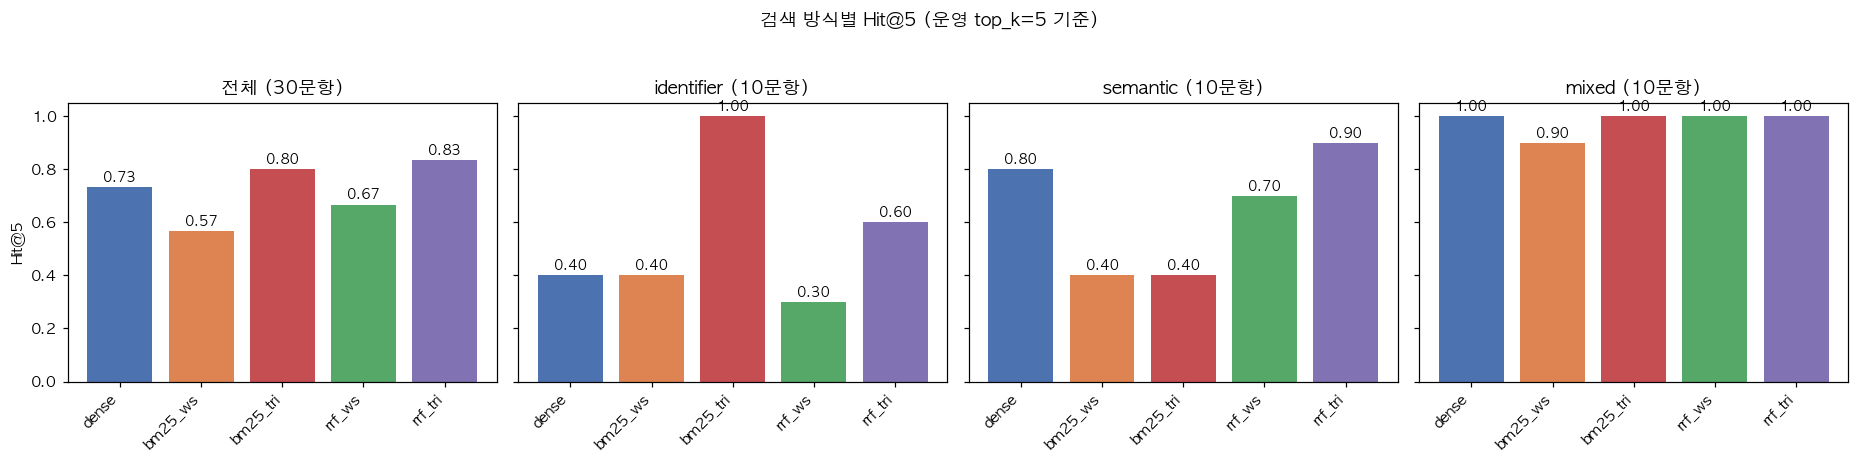

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), sharey=True)
x = np.arange(len(METHODS))
palette = ["#4C72B0", "#DD8452", "#C44E52", "#55A868", "#8172B3"]

panels = [("전체 (30문항)", overall["hit5"])] + [
    (f"{c} (10문항)", by_cat[c]["hit5"]) for c in CATS
]
for ax, (title, data) in zip(axes, panels):
    vals = [data[m] for m in METHODS]
    ax.bar(x, vals, color=palette)
    ax.set_xticks(x); ax.set_xticklabels(METHODS, rotation=45, ha="right")
    ax.set_title(title); ax.set_ylim(0, 1.05)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
axes[0].set_ylabel("Hit@5")
plt.suptitle("검색 방식별 Hit@5 (운영 top_k=5 기준)", y=1.04)
plt.tight_layout()
plt.savefig(FIG / "02-1_hit5_by_category.png", bbox_inches="tight")
plt.show()

## 6. 질문별 상세

평균은 실패를 감춘다. **어느 문항에서 갈렸는지**를 봐야 결정을 내릴 수 있다.
`-`는 상위 10개 안에 정답이 아예 없었다는 뜻이다.

In [9]:
idx = {(r["qid"], r["method"]): r for r in rows}

print(f"{'문항':<5} {'정답':>4}  {'질문':<42} " + " ".join(f"{m:>9}" for m in METHODS))
print("-" * 120)
for q in evalset:
    cells_ = []
    for m in METHODS:
        fr = idx[(q["id"], m)]["first_rank"]
        cells_.append(f"{fr:>9}" if fr else f"{'-':>9}")
    qt = q["question"][:40]
    print(f"{q['id']:<5} {q['gold_count']:>4}  {qt:<42} " + " ".join(cells_))
print()
print("표의 숫자 = 첫 정답이 나온 등수 (낮을수록 좋음, 6 이상이면 운영 top_k=5에서 탈락)")

문항      정답  질문                                             dense   bm25_ws  bm25_tri    rrf_ws   rrf_tri
------------------------------------------------------------------------------------------------------------------------
A01      1  WF-207이 무슨 업무야?                                    -         -         1         -         -
A02      1  WF-195 알려줘                                         3         1         1         1         2
A03      1  WF-233은 어떤 내용이야?                                   -         -         1         -         -
A04      1  WF-259가 뭐지?                                        3         -         1         -         1
A05      1  WF-264 업무 설명해줘                                     -         1         1         3         4
A06      1  WF-184가 뭐야?                                        4         -         1         -         1
A07      1  WF-238 관련 업무 알려줘                                   -         1         1         -         -
A08      1  WF-256이 뭔지 알려줘             

### 느슨한 라벨이 결론을 좌우하는지 확인

정답 집합이 크면 아무거나 뽑아도 맞아서 점수가 실력인지 운인지 구분되지 않는다.
`02`가 계산해 둔 문항별 **우연 적중률**(`chance_hit5`)이 20%를 넘는 문항을 빼고도
순위가 같은지 확인한다. 순위가 바뀌면 라벨을 조여야 한다.

느슨 문항 목록을 `source_meta.json`에서 읽지 않고 **`evalset.json`에서 직접 계산**한다.
노트북을 순서대로 돌리지 않거나 `02`를 옛 버전으로 되돌리면 두 파일의 내용이 어긋나는데,
같은 파일에서 파생시키면 그런 불일치가 생길 수 없다.

In [10]:
CHANCE_LIMIT = 0.20

missing = [q["id"] for q in evalset if "chance_hit5" not in q]
if missing:
    raise KeyError(
        f"evalset.json에 chance_hit5가 없습니다({len(missing)}문항). "
        "노트북 02를 최신 버전으로 다시 실행해 평가셋을 재생성하세요."
    )

LOOSE = {q["id"] for q in evalset if q["chance_hit5"] > CHANCE_LIMIT}
print(f"느슨 문항 (우연 적중률 >{CHANCE_LIMIT:.0%}):", sorted(LOOSE) or "없음")
for q in evalset:
    if q["id"] in LOOSE:
        print(f"  {q['id']}  정답 {q['gold_count']:>3}건  우연 {q['chance_hit5']:.1%}  {q['question']}")
print()

tight_rows = [r for r in rows if r["qid"] not in LOOSE]
tight = {k: agg(tight_rows, k) for k in ("hit5", "mrr", "ndcg")}

print(f"{'검색기':<10} {'Hit@5(전체)':>12} {'Hit@5(느슨 제외)':>18} {'차이':>8}")
print("-" * 52)
for m in METHODS:
    a, b = overall["hit5"][m], tight["hit5"][m]
    print(f"{m:<10} {a:>12.3f} {b:>18.3f} {b - a:>+8.3f}")

rank_all = sorted(METHODS, key=lambda m: -overall["hit5"][m])
rank_tight = sorted(METHODS, key=lambda m: -tight["hit5"][m])
print()
print("전체 순위     :", " > ".join(rank_all))
print("느슨 제외 순위:", " > ".join(rank_tight))
print("=> 순위 동일" if rank_all == rank_tight else "=> !! 순위가 바뀜 - 라벨 재검토 필요")

느슨 문항 (우연 적중률 >20%): ['B03', 'B08']
  B03  정답  21건  우연 25.0%  외부 평가자가 팀원 성과를 확인하는 기능은?
  B08  정답  25건  우연 29.1%  슬라이드 만드는 건 누가 하기로 했어?

검색기           Hit@5(전체)       Hit@5(느슨 제외)       차이
----------------------------------------------------
dense             0.733              0.786   +0.052
bm25_ws           0.567              0.536   -0.031
bm25_tri          0.800              0.857   +0.057
rrf_ws            0.667              0.679   +0.012
rrf_tri           0.833              0.857   +0.024

전체 순위     : rrf_tri > bm25_tri > dense > rrf_ws > bm25_ws
느슨 제외 순위: bm25_tri > rrf_tri > dense > rrf_ws > bm25_ws
=> !! 순위가 바뀜 - 라벨 재검토 필요


## 7. 저장

In [11]:
result = {
    "config": {"top_k": TOP_K, "depth": DEPTH, "rrf_k": RRF_K,
               "model": MODEL_NAME, "revision": MODEL_REVISION,
               "project_id": 1, "n_chunks": len(chunks), "n_questions": len(evalset)},
    "overall": overall,
    "by_category": by_cat,
    "overall_excluding_loose": tight,
    "rows": rows,
}
path = DATA / "results.json"
path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
print("저장:", path.relative_to(ROOT), f"({path.stat().st_size/1e3:.0f} KB)")

저장: output/hybrid_rag_eval/data/results.json (43 KB)


## 정리

검색기 5종을 30문항에 돌려 `Hit@5` · `MRR@10` · `nDCG@10`을 냈다.
숫자 해석과 도입 여부 판단은 다음 노트북 `02-2`에서 한다.